# Projet Time Series

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd

from tslearn.datasets import UCR_UEA_datasets

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset

from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb

import momentfm
from momentfm import MOMENTPipeline

from chronos import ChronosPipeline

In [4]:
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data analysis

In [6]:
print(f"Format X_train : {X_train.shape}") # (nb_samples, nb_timestamps, nb_features)

print(f"Nombre de classes : {len(set(y_train))}")

Format X_train : (2459, 36, 6)
Nombre de classes : 14


In [7]:
print(X_train.shape,
y_train.shape,
X_test.shape,
y_train.shape)

(2459, 36, 6) (2459,) (2466, 36, 6) (2459,)


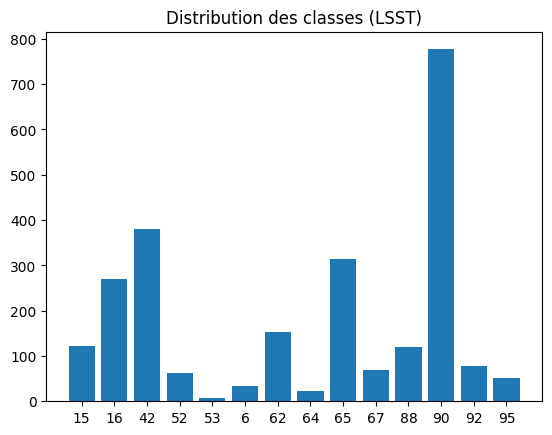

In [8]:
# Distribution des classes
classes, counts = np.unique(y_train, return_counts=True)
plt.bar(classes, counts)
plt.title("Distribution des classes (LSST)")
plt.show()

The classes are heavily imbalanced. We must pay attention to the F1-score when evaluating our models. We might also use the weight parameter in CrossEntropyLoss

In [9]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

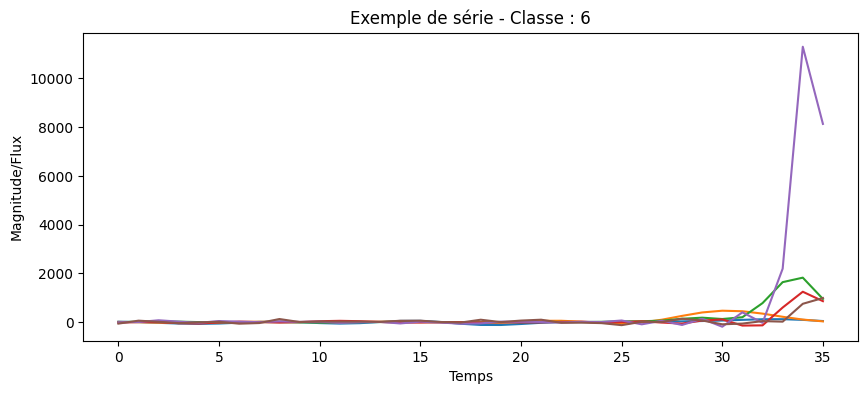

In [10]:
# Visualisation d'une série temporelle
# On affiche la première série (toutes ses features)
plt.figure(figsize=(10, 4))
plt.plot(X_train[0])
plt.title(f"Exemple de série - Classe : {y_train[0]}")
plt.xlabel("Temps")
plt.ylabel("Magnitude/Flux")
plt.show()

#### Universal Functions  

The following functions will be used for various models throughout the benchmark.

In [56]:
def train_and_eval_epoch(model, classifier, dataloader, optimizer, criterion, freeze_encoder, is_training=True):
    target_model = model.model if hasattr(model, 'model') and not hasattr(model, 'train') else model
    
    if is_training:
        if hasattr(target_model, 'train'): target_model.train() if not freeze_encoder else target_model.eval()
        classifier.train()
    else:
        if hasattr(target_model, 'eval'): target_model.eval()
        classifier.eval()

    total_loss, all_preds, all_targets = 0, [], []
    grad_env = torch.set_grad_enabled(is_training)
    
    with grad_env:
        for batch_X, batch_y in dataloader:
            batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
            if batch_X.shape[1] == 36: batch_X = batch_X.transpose(1, 2)
            if is_training: optimizer.zero_grad()
            
            if "ChronosPipeline" in str(type(model)): # Cas CHRONOS
                B, C, T = batch_X.shape
                x_flat = batch_X.reshape(B * C, T).cpu() 
                
                outputs_tuple = model.embed(x_flat) 
                embeddings = outputs_tuple[0] # On prend uniquement les embeddings
                
                pooled = embeddings.mean(dim=1).to(DEVICE) 
                features = pooled.view(B, C, -1).mean(dim=1)
                logits = classifier(features)
                
            elif hasattr(model, 'embed'): # Cas MOMENT
                batch_X_pad = F.pad(batch_X, (0, 512 - batch_X.shape[-1]))
                
                if is_training and not freeze_encoder:
                    batch_X_pad.requires_grad_(True) 
                    
                outputs = model.embed(x_enc=batch_X_pad)
                embeddings = outputs.embeddings if hasattr(outputs, 'embeddings') else outputs
                features = embeddings.mean(dim=1) if embeddings.dim() == 3 else embeddings
                logits = classifier(features)
            else: # Cas BASELINES
                logits = model(batch_X.transpose(1, 2))
            
            loss = criterion(logits, batch_y)
            if is_training:
                loss.backward()
                optimizer.step()
            
            total_loss += loss.item()
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    acc = accuracy_score(all_targets, all_preds)
    return avg_loss, acc, f1

In [57]:
def plot_confusion_matrix(model, classifier, dataloader, le, title="Matrice de Confusion"):
    target_model = model.model if hasattr(model, 'model') and not hasattr(model, 'eval') else model
    
    if hasattr(target_model, 'eval'):
        target_model.eval()
    classifier.eval()
    
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X = batch_X.to(DEVICE)
            
            # Prétraitement standard
            if batch_X.shape[1] == 36: batch_X = batch_X.transpose(1, 2)
            
            if "ChronosPipeline" in str(type(model)):
                B, C, T = batch_X.shape
                x_flat = batch_X.reshape(B * C, T).cpu()
                outputs_tuple = model.embed(x_flat)
                embeddings = outputs_tuple[0]
                pooled = embeddings.mean(dim=1).to(DEVICE)
                features = pooled.view(B, C, -1).mean(dim=1)
                logits = classifier(features)
                
            elif hasattr(model, 'embed'):
                # Cas MOMENT
                batch_X_pad = F.pad(batch_X, (0, 512 - batch_X.shape[-1]))
                outputs = model.embed(x_enc=batch_X_pad)
                embeddings = outputs.embeddings if hasattr(outputs, 'embeddings') else outputs
                features = embeddings.mean(dim=1) if embeddings.dim() == 3 else embeddings
                logits = classifier(features)
            else:
                # Cas BASELINES (Oracle)
                logits = model(batch_X.transpose(1, 2))
            
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
    
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(12, 9))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Purples')
    plt.xlabel('Prédit')
    plt.ylabel('Réel')
    plt.title(title)
    plt.show()

In [13]:
BATCH_SIZE = 32

# Encodage des labels de 0 à C-1 (C le nb de classes)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
num_classes = len(le.classes_)

# Les données sont (N, 36, 6), PyTorch Conv1D attend (N, 6, 36)
X_train_t = torch.tensor(X_train, dtype=torch.float32).transpose(1, 2).to(DEVICE)
y_train_t = torch.tensor(y_train_encoded, dtype=torch.long).to(DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32).transpose(1, 2).to(DEVICE)
y_test_t = torch.tensor(y_test_encoded, dtype=torch.long).to(DEVICE)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE)



## Baseline

##### 1D CNN

In [14]:
class TimeSeriesCNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # On s'attend à recevoir (B, T, C), donc on transpose pour Conv1d (B, C, T)
            nn.Conv1d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), 
            nn.GELU(),
            
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), 
            nn.GELU(),

            nn.AdaptiveAvgPool1d(8),
            
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), 
            nn.GELU(),

            nn.AdaptiveAvgPool1d(1)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x arrive en (B, T, C) via la fonction universelle
        x = x.transpose(1, 2) # Devient (B, C, T) pour les Conv1d
        x = self.features(x)
        return self.classifier(x)

In [15]:
def run_cnn_experiment(epochs, lr, weights_tensor):
    print(f"Initialisation de la Baseline CNN...")
    
    # Initialisation du modèle
    # in_channels = 6 (nb de filtres LSST)
    model = TimeSeriesCNN(in_channels=6, num_classes=num_classes).to(DEVICE)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)

    history = {'train_f1': [], 'test_f1': [], 'train_loss': [], 'test_loss': []}

    for epoch in range(epochs): #
        # On utilise la fonction universelle (classifier = nn.Identity car déjà inclus)
        tr_loss, tr_acc, tr_f1 = train_and_eval_epoch(
            model, nn.Identity(), train_loader, optimizer, criterion, False, is_training=True
        )
        ts_loss, ts_acc, ts_f1 = train_and_eval_epoch(
            model, nn.Identity(), test_loader, optimizer, criterion, False, is_training=False
        )
        
        # Sauvegarde de l'historique
        history['train_f1'].append(tr_f1)
        history['test_f1'].append(ts_f1)
        history['train_loss'].append(tr_loss)
        history['test_loss'].append(ts_loss)
        
        if (epoch + 1) % 5 == 0:
            print(f"CNN Epoch [{epoch+1}/{epochs}] | Train F1: {tr_f1:.4f} | Test F1: {ts_f1:.4f} | Loss: {tr_loss:.4f}")

    return model, history

In [16]:
cnn_model, cnn_history = run_cnn_experiment(
    epochs=100, 
    lr=0.001, 
    weights_tensor=weights_tensor
)

Initialisation de la Baseline CNN...
CNN Epoch [5/100] | Train F1: 0.2668 | Test F1: 0.2428 | Loss: 1.9448
CNN Epoch [10/100] | Train F1: 0.3627 | Test F1: 0.3132 | Loss: 1.6995
CNN Epoch [15/100] | Train F1: 0.4113 | Test F1: 0.3350 | Loss: 1.5081
CNN Epoch [20/100] | Train F1: 0.4169 | Test F1: 0.3319 | Loss: 1.5109
CNN Epoch [25/100] | Train F1: 0.4406 | Test F1: 0.3020 | Loss: 1.4097
CNN Epoch [30/100] | Train F1: 0.4241 | Test F1: 0.3566 | Loss: 1.4255
CNN Epoch [35/100] | Train F1: 0.4934 | Test F1: 0.3438 | Loss: 1.2748
CNN Epoch [40/100] | Train F1: 0.4849 | Test F1: 0.4409 | Loss: 1.2342
CNN Epoch [45/100] | Train F1: 0.5174 | Test F1: 0.3188 | Loss: 1.1351
CNN Epoch [50/100] | Train F1: 0.4482 | Test F1: 0.2783 | Loss: 1.3269
CNN Epoch [55/100] | Train F1: 0.5042 | Test F1: 0.3028 | Loss: 1.1881
CNN Epoch [60/100] | Train F1: 0.5495 | Test F1: 0.4078 | Loss: 1.0642
CNN Epoch [65/100] | Train F1: 0.5538 | Test F1: 0.3374 | Loss: 1.0309
CNN Epoch [70/100] | Train F1: 0.5474 | T

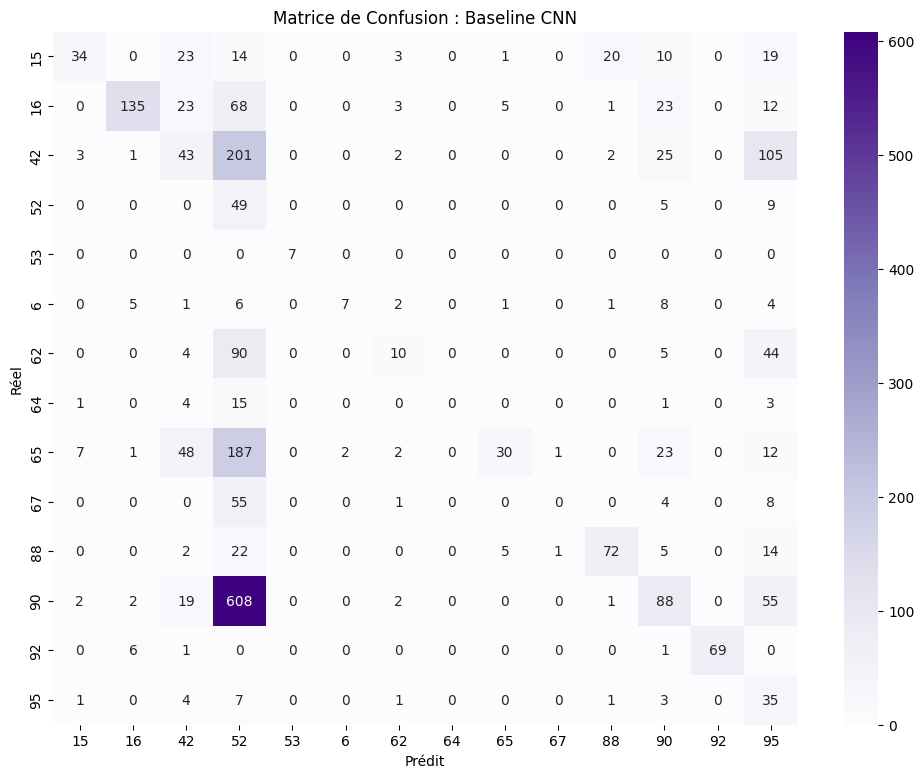

In [17]:
plot_confusion_matrix(
    cnn_model, 
    nn.Identity(), 
    test_loader, 
    le, 
    title="Matrice de Confusion : Baseline CNN")

##### ORACLE (GRU based)

In [18]:
class ORACLEModel(nn.Module):
    def __init__(self, n_channels=6, hidden_dim=128, num_classes=14, num_layers=2):
        super(ORACLEModel, self).__init__()

        self.gru = nn.GRU(
            input_size=n_channels, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True, 
            bidirectional=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        # 2 * hidden_dim car bidirectionnel
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x shape: [Batch, Time=36, Channels=6]
        # hn: [num_layers * 2, Batch, hidden_dim]
        _, hn = self.gru(x)
        # On concatène le dernier état caché des deux directions (avant et arrière)
        out = torch.cat((hn[-2,:,:], hn[-1,:,:]), dim=1)
        return self.classifier(out)

In [19]:
def run_oracle_experiment(epochs, lr):
    model = ORACLEModel(n_channels=6, num_classes=num_classes).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    
    history = {'train_loss': [], 'test_loss': [], 'train_f1': [], 'test_f1': []}
    
    for epoch in range(epochs): #
        tr_loss, tr_acc, tr_f1 = train_and_eval_epoch(model, nn.Identity(), train_loader, optimizer, criterion, False, is_training=True)
        ts_loss, ts_acc, ts_f1 = train_and_eval_epoch(model, nn.Identity(), test_loader, optimizer, criterion, False, is_training=False)
        
        history['train_f1'].append(tr_f1)
        history['test_f1'].append(ts_f1)
        history['train_loss'].append(tr_loss)
        history['test_loss'].append(ts_loss)
        
        if (epoch+1)%5 == 0 :
            # Affichage identique pour comparer
            print(f"ORACLE Epoch [{epoch+1}/{epochs}] | Train F1: {tr_f1:.4f} | Test F1: {ts_f1:.4f} | Loss: {tr_loss:.4f}")
    
    return model, history

In [20]:
oracle_model, oracle_hist = run_oracle_experiment(epochs=100, lr=1e-3)

ORACLE Epoch [5/100] | Train F1: 0.5783 | Test F1: 0.4353 | Loss: 0.8514
ORACLE Epoch [10/100] | Train F1: 0.7752 | Test F1: 0.5068 | Loss: 0.3793
ORACLE Epoch [15/100] | Train F1: 0.8998 | Test F1: 0.5121 | Loss: 0.1610
ORACLE Epoch [20/100] | Train F1: 0.9826 | Test F1: 0.5206 | Loss: 0.0418
ORACLE Epoch [25/100] | Train F1: 0.8792 | Test F1: 0.5095 | Loss: 0.2073
ORACLE Epoch [30/100] | Train F1: 0.9954 | Test F1: 0.5032 | Loss: 0.0165
ORACLE Epoch [35/100] | Train F1: 0.9597 | Test F1: 0.5232 | Loss: 0.0593
ORACLE Epoch [40/100] | Train F1: 1.0000 | Test F1: 0.5366 | Loss: 0.0022
ORACLE Epoch [45/100] | Train F1: 1.0000 | Test F1: 0.5384 | Loss: 0.0010
ORACLE Epoch [50/100] | Train F1: 1.0000 | Test F1: 0.5298 | Loss: 0.0006
ORACLE Epoch [55/100] | Train F1: 1.0000 | Test F1: 0.5260 | Loss: 0.0005
ORACLE Epoch [60/100] | Train F1: 1.0000 | Test F1: 0.5298 | Loss: 0.0003
ORACLE Epoch [65/100] | Train F1: 1.0000 | Test F1: 0.5289 | Loss: 0.0002
ORACLE Epoch [70/100] | Train F1: 1.000

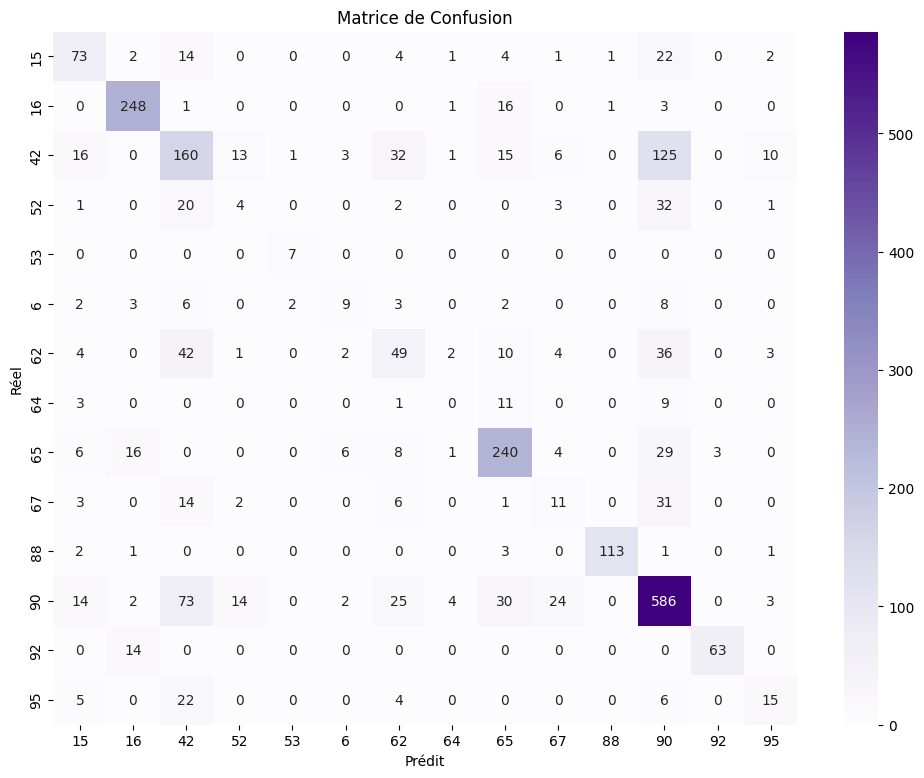

In [21]:
plot_confusion_matrix(oracle_model, nn.Identity(), test_loader, le)

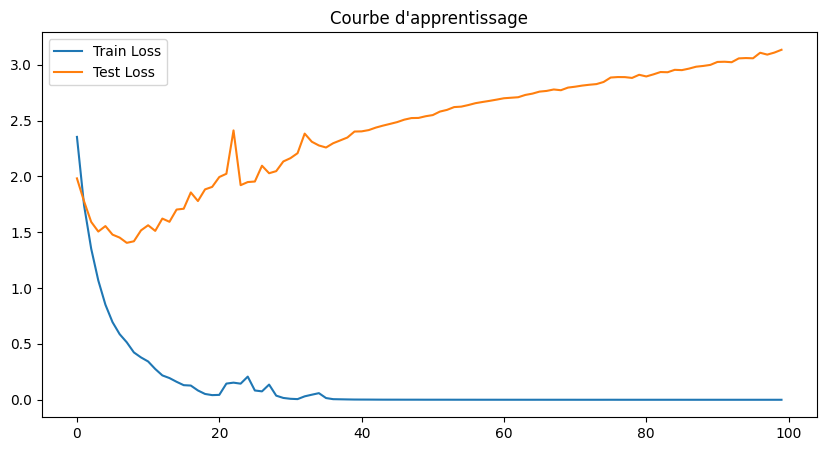

In [22]:
# quick verification of overfitting
plt.figure(figsize=(10, 5))
plt.plot(oracle_hist['train_loss'], label='Train Loss')
plt.plot(oracle_hist['test_loss'], label='Test Loss')
plt.title('Courbe d\'apprentissage')
plt.legend()
plt.show()

ORACLE has the best test F1 despite being massively overfitted !

#### LigthGBM

In [51]:
def run_lgbm_experiment(X_train, y_train, X_test, y_test, num_classes):
    print("Préparation des données pour LightGBM (Aplatissement)...")
    
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)

    lgb_train = lgb.Dataset(X_train_flat, label=y_train)
    lgb_eval = lgb.Dataset(X_test_flat, label=y_test, reference=lgb_train)

    params = {
        'objective': 'multiclass',
        'num_class': num_classes,
        'metric': 'multi_logloss',
        'boosting_type': 'gbdt',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'feature_fraction': 0.8,
        'verbose': -1,
        'random_state': 42
    }

    print("Début de l'entraînement LightGBM...")
    evals_result = {}
    
    gbm = lgb.train(
        params, 
        lgb_train, 
        num_boost_round=150, 
        valid_sets=[lgb_train, lgb_eval],
        valid_names=['train', 'eval'],
        callbacks=[lgb.record_evaluation(evals_result)]
    )

    y_pred_prob = gbm.predict(X_test_flat)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    final_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    final_acc = accuracy_score(y_test, y_pred)
    
    history = {
        'train_loss': evals_result['train']['multi_logloss'],
        'test_loss': evals_result['eval']['multi_logloss'],
        'final_f1': final_f1,
        'final_acc': final_acc
    }

    print(f"LightGBM Terminé | Test F1: {final_f1:.4f} | Test Acc: {final_acc:.4f}")
    return gbm, history

In [53]:
def plot_lgbm_confusion_matrix(model, X_test, y_test, le, title="Matrice de Confusion : LightGBM"):
    X_test_flat = X_test.reshape(X_test.shape[0], -1)
    
    y_pred_prob = model.predict(X_test_flat)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 9))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Purples')
    plt.xlabel('Prédit')
    plt.ylabel('Réel')
    plt.title(title)
    plt.show()

Préparation des données pour LightGBM (Aplatissement)...
Début de l'entraînement LightGBM...
LightGBM Terminé | Test F1: 0.3338 | Test Acc: 0.5474


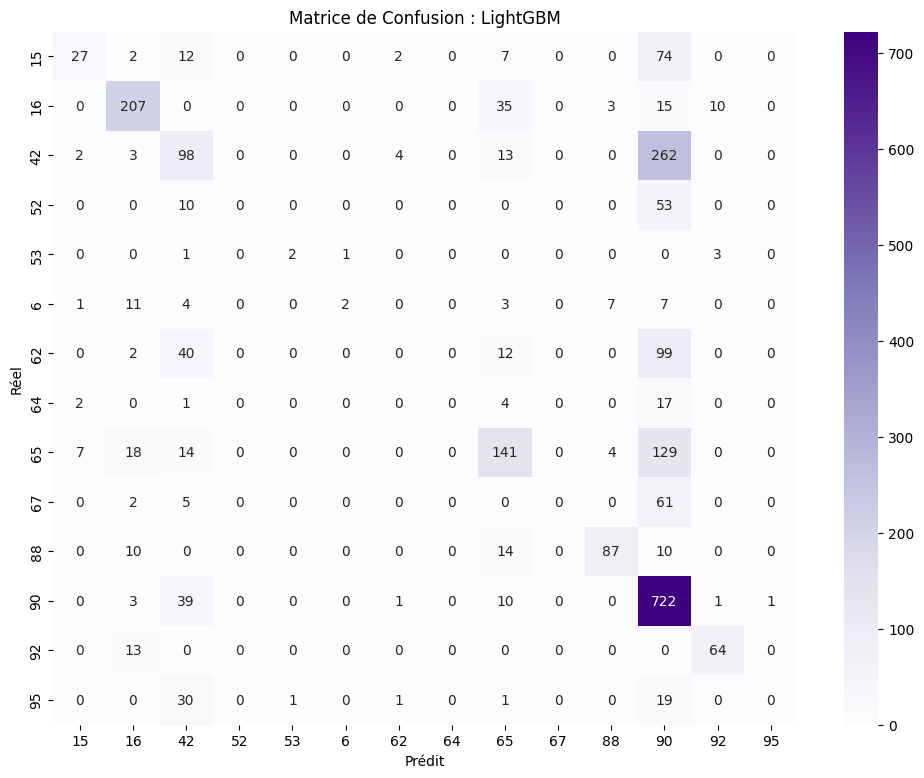

In [54]:
lgbm_model, lgbm_history = run_lgbm_experiment(X_train, y_train_encoded, X_test, y_test_encoded, num_classes)
plot_lgbm_confusion_matrix(lgbm_model, X_test, y_test_encoded, le)

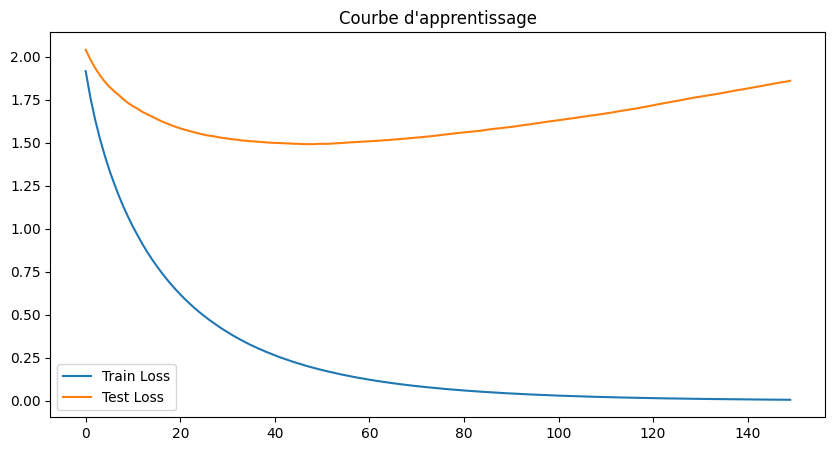

In [55]:
# quick verification of overfitting
plt.figure(figsize=(10, 5))
plt.plot(lgbm_history['train_loss'], label='Train Loss')
plt.plot(lgbm_history['test_loss'], label='Test Loss')
plt.title('Courbe d\'apprentissage')
plt.legend()
plt.show()

## Setting 1 : Adapt a foundation model

In [58]:
def get_moment_model(model_id, num_classes, freeze_encoder=True):
    model = MOMENTPipeline.from_pretrained(
        model_id, 
        model_kwargs={
            "task_name": "embedding", 
            "n_channels": 6, 
            "seq_len": 512, 
            "freeze_encoder": freeze_encoder
        }
    ).to(DEVICE)

    hidden_dim = model.config.d_model 
    classifier = nn.Linear(hidden_dim, num_classes).to(DEVICE)
    
    return model, classifier

In [59]:
def run_experiment(model_id, freeze_encoder, epochs, lr):
    model, classifier = get_moment_model(model_id, num_classes, freeze_encoder)
    
    params = [
        {'params': model.parameters(), 'lr': lr}, 
        {'params': classifier.parameters(), 'lr': lr * 10}
    ]
    optimizer = torch.optim.AdamW(params)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)

    history = {
        'train_loss': [], 'test_loss': [],
        'train_f1': [], 'test_f1': []
    }

    for epoch in range(epochs): #
        train_loss, train_acc, train_f1 = train_and_eval_epoch(
            model, classifier, train_loader, optimizer, criterion, freeze_encoder, is_training=True
        )
        
        test_loss, test_acc, test_f1 = train_and_eval_epoch(
            model, classifier, test_loader, optimizer, criterion, freeze_encoder, is_training=False
        )
        
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_f1'].append(train_f1)
        history['test_f1'].append(test_f1)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Train F1: {train_f1:.4f} vs Test F1: {test_f1:.4f}")

    return model, classifier, history

#### Moment : Linear probing

In [25]:
print("Lancement du Linear Probing (MOMENT-small)...")
model_lp, classifier_lp, history_lp = run_experiment(model_id="AutonLab/MOMENT-1-small", freeze_encoder=True, epochs=20, lr=1e-3)

Lancement du Linear Probing (MOMENT-small)...


config.json:   0%|          | 0.00/947 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/152M [00:00<?, ?B/s]

Epoch [1/20] | Train F1: 0.0870 vs Test F1: 0.1472
Epoch [2/20] | Train F1: 0.1449 vs Test F1: 0.1459
Epoch [3/20] | Train F1: 0.1599 vs Test F1: 0.1660
Epoch [4/20] | Train F1: 0.1881 vs Test F1: 0.1780
Epoch [5/20] | Train F1: 0.2000 vs Test F1: 0.1879
Epoch [6/20] | Train F1: 0.2223 vs Test F1: 0.2017
Epoch [7/20] | Train F1: 0.2178 vs Test F1: 0.1582
Epoch [8/20] | Train F1: 0.2297 vs Test F1: 0.2092
Epoch [9/20] | Train F1: 0.2436 vs Test F1: 0.1614
Epoch [10/20] | Train F1: 0.2279 vs Test F1: 0.1912
Epoch [11/20] | Train F1: 0.2508 vs Test F1: 0.2369
Epoch [12/20] | Train F1: 0.2511 vs Test F1: 0.2071
Epoch [13/20] | Train F1: 0.2390 vs Test F1: 0.2274
Epoch [14/20] | Train F1: 0.2735 vs Test F1: 0.2371
Epoch [15/20] | Train F1: 0.2558 vs Test F1: 0.2032
Epoch [16/20] | Train F1: 0.2544 vs Test F1: 0.2479
Epoch [17/20] | Train F1: 0.2823 vs Test F1: 0.2370
Epoch [18/20] | Train F1: 0.2729 vs Test F1: 0.2228
Epoch [19/20] | Train F1: 0.2695 vs Test F1: 0.2430
Epoch [20/20] | Train

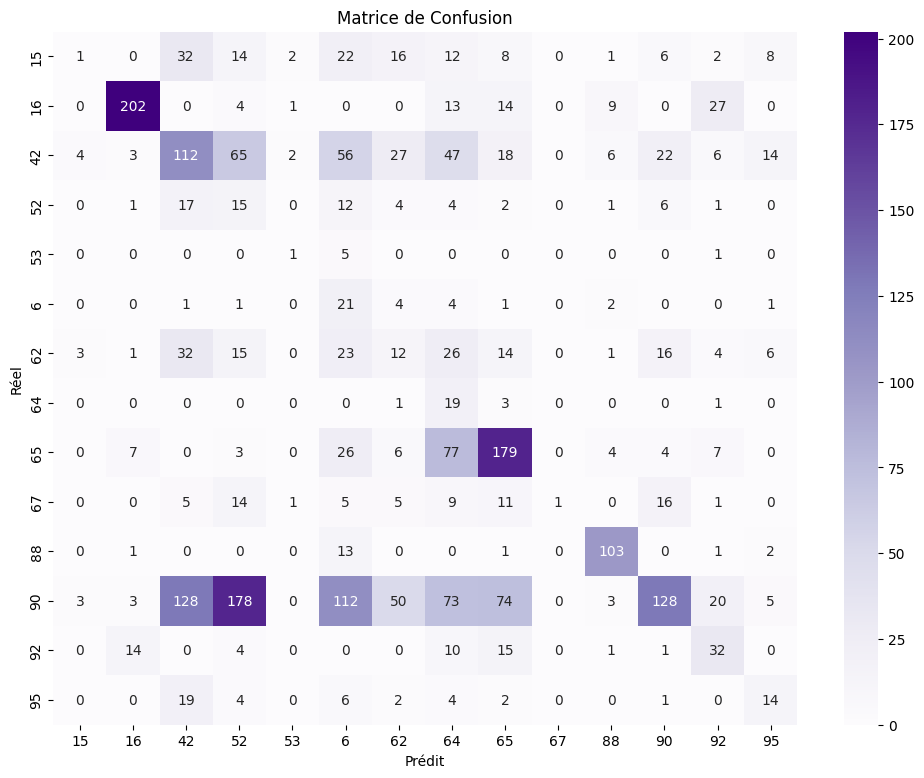

In [26]:
plot_confusion_matrix(model_lp, classifier_lp, test_loader, le)

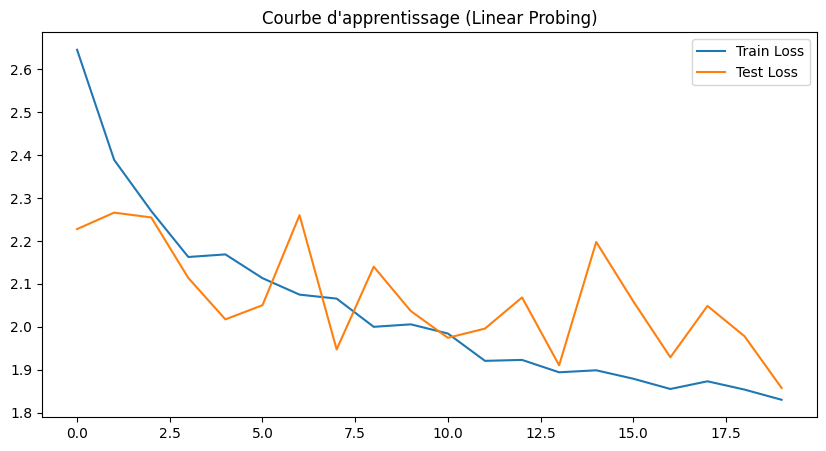

In [27]:
# quick verification of overfitting
plt.figure(figsize=(10, 5))
plt.plot(history_lp['train_loss'], label='Train Loss')
plt.plot(history_lp['test_loss'], label='Test Loss')
plt.title('Courbe d\'apprentissage (Linear Probing)')
plt.legend()
plt.show()

#### Moment : Fine-tuning

In [60]:
print("\nLancement du Fine-Tuning (MOMENT-small)...")
model_ft, classifier_ft, history_ft = run_experiment(model_id="AutonLab/MOMENT-1-small", freeze_encoder=False, epochs=10, lr=1e-5)


Lancement du Fine-Tuning (MOMENT-small)...
Epoch [1/10] | Train F1: 0.0449 vs Test F1: 0.0667
Epoch [2/10] | Train F1: 0.1513 vs Test F1: 0.1697
Epoch [3/10] | Train F1: 0.1984 vs Test F1: 0.2222
Epoch [4/10] | Train F1: 0.2278 vs Test F1: 0.2511
Epoch [5/10] | Train F1: 0.2538 vs Test F1: 0.2802
Epoch [6/10] | Train F1: 0.2870 vs Test F1: 0.3009
Epoch [7/10] | Train F1: 0.3128 vs Test F1: 0.3155
Epoch [8/10] | Train F1: 0.3284 vs Test F1: 0.3150
Epoch [9/10] | Train F1: 0.3221 vs Test F1: 0.3317
Epoch [10/10] | Train F1: 0.3838 vs Test F1: 0.3555


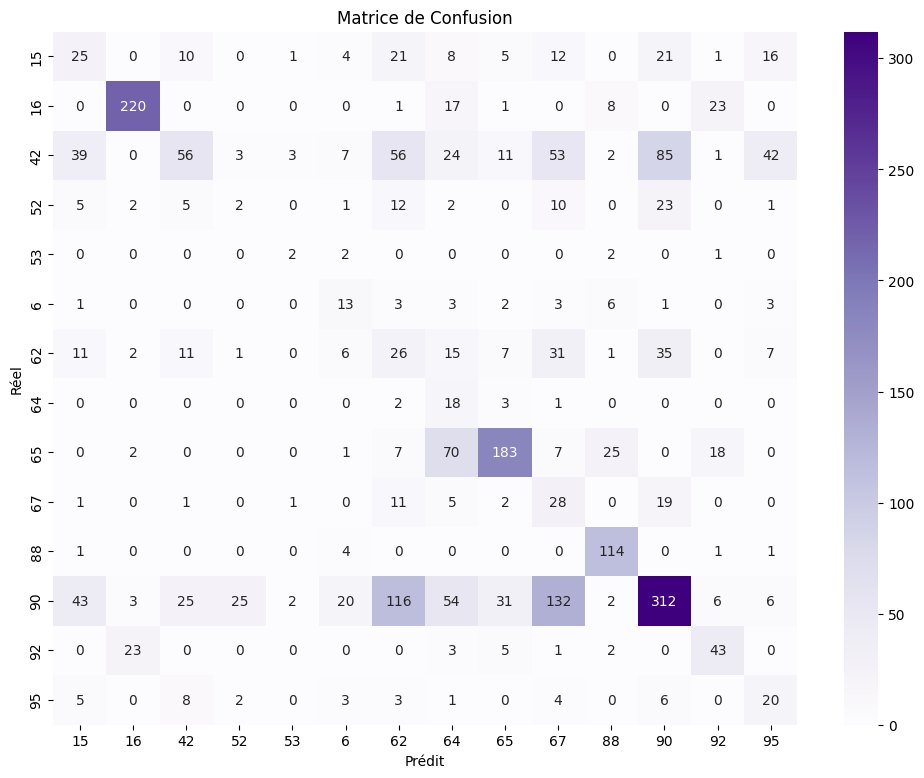

In [61]:
plot_confusion_matrix(model_ft, classifier_ft, test_loader, le)

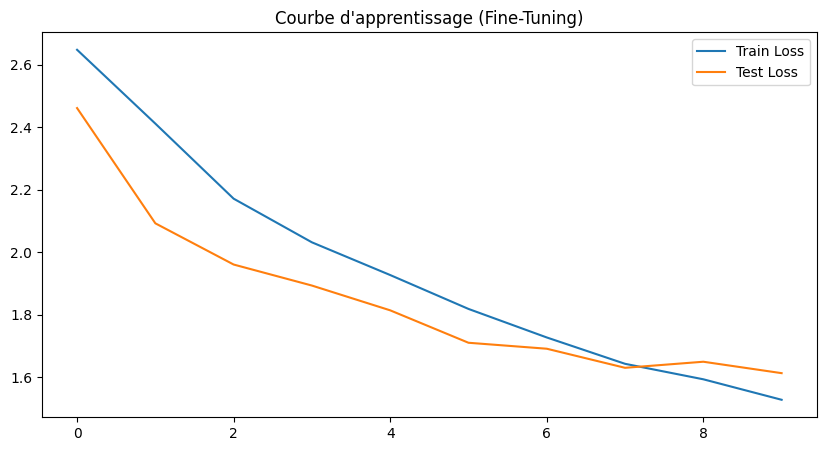

In [62]:
# quick verification of overfitting
plt.figure(figsize=(10, 5))
plt.plot(history_ft['train_loss'], label='Train Loss')
plt.plot(history_ft['test_loss'], label='Test Loss')
plt.title('Courbe d\'apprentissage (Fine-Tuning)')
plt.legend()
plt.show()

#### Moment : Deep Probing

In [78]:
def get_deep_head(num_classes):
    return nn.Sequential(
        nn.LazyLinear(512),
        nn.BatchNorm1d(512),
        nn.GELU(),
        nn.Dropout(0.5),
        nn.Linear(512, 128),
        nn.BatchNorm1d(128),
        nn.GELU(),
        nn.Dropout(0.3),
        nn.Linear(128, num_classes),
    ).to(DEVICE)

In [86]:
# 1. Charger MOMENT (Encodeur gelé)
model_moment, _ = get_moment_model("AutonLab/MOMENT-1-small", num_classes, freeze_encoder=True)

# 2. Créer la tête complexe (MLP)
deep_classifier = nn.Sequential(
    nn.LazyLinear(512),
    nn.BatchNorm1d(512),
    nn.GELU(),
    nn.Dropout(0.5),
    nn.Linear(512, 128),
    nn.BatchNorm1d(128),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(128, num_classes),
).to(DEVICE)

# 3. Initialisation des couches "Lazy" (Batch size de 2 pour le BatchNorm)
with torch.no_grad():
    dummy_input = torch.randn(2, 512).to(DEVICE)
    deep_classifier(dummy_input)

# 4. Configuration de l'optimiseur (Uniquement sur la tête)
optimizer = torch.optim.AdamW(deep_classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

# 5. Boucle d'entraînement utilisant TA fonction universelle
print("Début du Deep Probing...")
history_deep = {'train_f1': [], 'test_f1': []}

for epoch in range(10): #
    # Phase d'entraînement
    tr_loss, tr_acc, tr_f1 = train_and_eval_epoch(
        model_moment, deep_classifier, train_loader, optimizer, criterion, 
        freeze_encoder=True, is_training=True
    )
    
    # Phase de test
    ts_loss, ts_acc, ts_f1 = train_and_eval_epoch(
        model_moment, deep_classifier, test_loader, optimizer, criterion, 
        freeze_encoder=True, is_training=False
    )
    
    history_deep['train_f1'].append(tr_f1)
    history_deep['test_f1'].append(ts_f1)
    
    print(f"Epoch [{epoch+1}/{10}] | Train F1: {tr_f1:.4f} | Test F1: {ts_f1:.4f} | Loss: {tr_loss:.4f}")

Début du Deep Probing...
Epoch [1/10] | Train F1: 0.1763 | Test F1: 0.2207 | Loss: 2.2459
Epoch [2/10] | Train F1: 0.2517 | Test F1: 0.2418 | Loss: 1.9476
Epoch [3/10] | Train F1: 0.2594 | Test F1: 0.2166 | Loss: 1.8143
Epoch [4/10] | Train F1: 0.2867 | Test F1: 0.2744 | Loss: 1.7445
Epoch [5/10] | Train F1: 0.3104 | Test F1: 0.2215 | Loss: 1.6479
Epoch [6/10] | Train F1: 0.3012 | Test F1: 0.2876 | Loss: 1.6271
Epoch [7/10] | Train F1: 0.3174 | Test F1: 0.2740 | Loss: 1.5359
Epoch [8/10] | Train F1: 0.3191 | Test F1: 0.2552 | Loss: 1.5369
Epoch [9/10] | Train F1: 0.3291 | Test F1: 0.2215 | Loss: 1.4559
Epoch [10/10] | Train F1: 0.3462 | Test F1: 0.2322 | Loss: 1.4286


##### Chronos

In [31]:
CHRONOS_MODEL_ID = "amazon/chronos-t5-small" 

def get_chronos_model(model_id, num_classes, freeze_encoder=True):
    print(f"Chargement de Chronos : {model_id}...")
    
    pipeline = ChronosPipeline.from_pretrained(
        model_id,
        device_map=DEVICE, # Le modèle va sur le GPU
        torch_dtype=torch.float32,
    )
    
    # On s'assure que le tokenizer est bien sur le CPU
    if hasattr(pipeline.tokenizer, 'boundaries'):
        pipeline.tokenizer.boundaries = pipeline.tokenizer.boundaries.cpu()
    
    model = pipeline.model
    
    if freeze_encoder:
        for param in model.parameters():
            param.requires_grad = False

    # Récupération de la dimension
    if hasattr(model.config, 'model_config') and 'd_model' in model.config.model_config:
        hidden_dim = model.config.model_config['d_model']
    else:
        hidden_dim = getattr(model.config, 'd_model', 512)
    
    classifier = nn.Linear(hidden_dim, num_classes).to(DEVICE)
    return pipeline, classifier

In [32]:
def run_chronos_experiment(model_id, freeze_encoder, epochs, lr):
    print(f"Initialisation de Chronos ({model_id})...")

    pipeline, classifier = get_chronos_model(model_id, num_classes, freeze_encoder)
    
    # Configuration de l'optimiseur
    # Si freeze_encoder=True, on n'optimise que le classifier
    params = [{'params': classifier.parameters(), 'lr': lr * 10}]
    if not freeze_encoder:
        params.append({'params': pipeline.model.parameters(), 'lr': lr})
        
    optimizer = torch.optim.AdamW(params)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)

    history = {'train_loss': [], 'test_loss': [], 'train_f1': [], 'test_f1': []}

    for epoch in range(epochs):
        tr_loss, tr_acc, tr_f1 = train_and_eval_epoch(
            pipeline, classifier, train_loader, optimizer, criterion, freeze_encoder, is_training=True
        )
        ts_loss, ts_acc, ts_f1 = train_and_eval_epoch(
            pipeline, classifier, test_loader, optimizer, criterion, freeze_encoder, is_training=False
        )
        
        history['train_f1'].append(tr_f1)
        history['test_f1'].append(ts_f1)
        history['train_loss'].append(tr_loss)
        history['test_loss'].append(ts_loss)
        
        print(f"Chronos Epoch [{epoch+1}/{epochs}] | Train F1: {tr_f1:.4f} | Test F1: {ts_f1:.4f}")

    return pipeline, classifier, history

--- Lancement Chronos : Linear Probing ---
Initialisation de Chronos (amazon/chronos-t5-small)...
Chargement de Chronos : amazon/chronos-t5-small...


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Chronos Epoch [1/20] | Train F1: 0.1559 | Test F1: 0.1291
Chronos Epoch [2/20] | Train F1: 0.2048 | Test F1: 0.2068
Chronos Epoch [3/20] | Train F1: 0.2208 | Test F1: 0.1967
Chronos Epoch [4/20] | Train F1: 0.2200 | Test F1: 0.2615
Chronos Epoch [5/20] | Train F1: 0.2392 | Test F1: 0.2492
Chronos Epoch [6/20] | Train F1: 0.2711 | Test F1: 0.2387
Chronos Epoch [7/20] | Train F1: 0.2575 | Test F1: 0.2453
Chronos Epoch [8/20] | Train F1: 0.2595 | Test F1: 0.2798
Chronos Epoch [9/20] | Train F1: 0.2991 | Test F1: 0.2733
Chronos Epoch [10/20] | Train F1: 0.2938 | Test F1: 0.2674
Chronos Epoch [11/20] | Train F1: 0.2994 | Test F1: 0.2911
Chronos Epoch [12/20] | Train F1: 0.2880 | Test F1: 0.2953
Chronos Epoch [13/20] | Train F1: 0.3297 | Test F1: 0.2797
Chronos Epoch [14/20] | Train F1: 0.3338 | Test F1: 0.2887
Chronos Epoch [15/20] | Train F1: 0.3560 | Test F1: 0.2898
Chronos Epoch [16/20] | Train F1: 0.3319 | Test F1: 0.3063
Chronos Epoch [17/20] | Train F1: 0.3549 | Test F1: 0.2962
Chrono

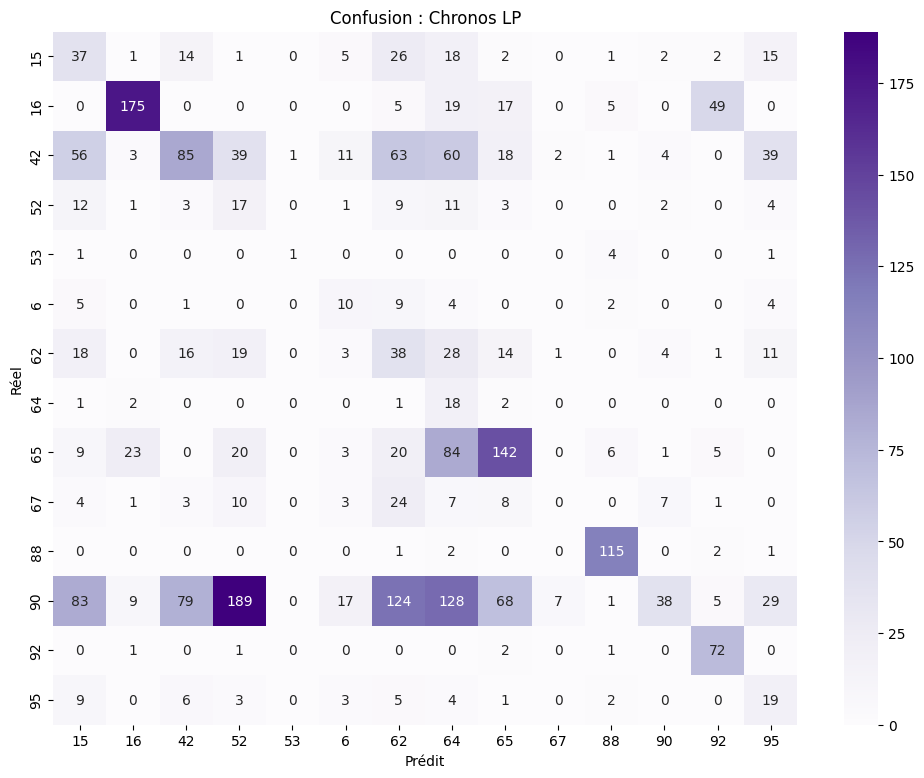

In [33]:
# CHRONOS LINEAR PROBING
print("--- Lancement Chronos : Linear Probing ---")
chronos_lp_pipe, chronos_lp_head, hist_lp = run_chronos_experiment(
    model_id="amazon/chronos-t5-small", 
    freeze_encoder=True, 
    epochs=20, #
    lr=1e-3
)
plot_confusion_matrix(chronos_lp_pipe, chronos_lp_head, test_loader, le, title="Confusion : Chronos LP")


--- Lancement Chronos : Fine-Tuning ---
Initialisation de Chronos (amazon/chronos-t5-small)...
Chargement de Chronos : amazon/chronos-t5-small...
Chronos Epoch [1/10] | Train F1: 0.0029 | Test F1: 0.0030
Chronos Epoch [2/10] | Train F1: 0.0231 | Test F1: 0.0310
Chronos Epoch [3/10] | Train F1: 0.0517 | Test F1: 0.0663
Chronos Epoch [4/10] | Train F1: 0.0818 | Test F1: 0.0798
Chronos Epoch [5/10] | Train F1: 0.0704 | Test F1: 0.0680
Chronos Epoch [6/10] | Train F1: 0.0694 | Test F1: 0.0855
Chronos Epoch [7/10] | Train F1: 0.0934 | Test F1: 0.1005
Chronos Epoch [8/10] | Train F1: 0.1028 | Test F1: 0.1030
Chronos Epoch [9/10] | Train F1: 0.0962 | Test F1: 0.1031
Chronos Epoch [10/10] | Train F1: 0.0883 | Test F1: 0.1044


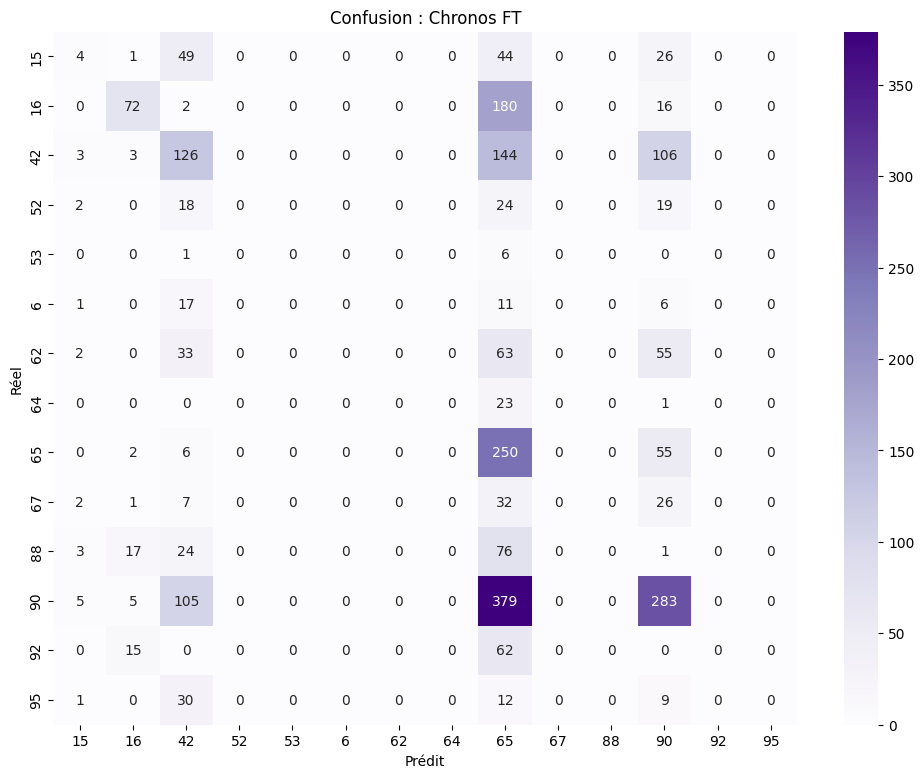

In [34]:
# CHRONOS FINE-TUNING
print("\n--- Lancement Chronos : Fine-Tuning ---")
# On utilise un Learning Rate plus faible (1e-5) pour ne pas casser l'encodeur
chronos_ft_pipe, chronos_ft_head, hist_ft = run_chronos_experiment(
    model_id="amazon/chronos-t5-small", 
    freeze_encoder=False, 
    epochs=10, # Le FT est souvent plus rapide à converger
    lr=1e-5
)
plot_confusion_matrix(chronos_ft_pipe, chronos_ft_head, test_loader, le, title="Confusion : Chronos FT")

## Setting 2 : Pre-training on forecasting tasks

In [35]:
# Téléchargement direct du dataset ETTh1 (7 variables)
url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df = pd.read_csv(url)
data = df.drop(columns=['date']).values

# Normalisation simple
data = (data - data.mean(axis=0)) / data.std(axis=0)

#### Pre training :

In [36]:
# Variable pour le nombre d'époques
N_EPOCHS_PRETRAIN = 40
BATCH_SIZE = 64
SEQ_LEN = 96  # Longueur de la fenêtre d'entrée
PRED_LEN = 1  # On prédit le point suivant
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [37]:
class InformerDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len

    def __getitem__(self, index):
        s_begin = index
        s_end = s_begin + self.seq_len
        r_begin = s_end
        r_end = r_begin + self.pred_len

        seq_x = self.data[s_begin:s_end]
        seq_y = self.data[r_begin:r_end]
        return seq_x, seq_y

train_ds = InformerDataset(data, SEQ_LEN, PRED_LEN)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

In [38]:
class TransformerForecaster(nn.Module):
    def __init__(self, n_features=7, d_model=128, nhead=8, num_layers=3):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=512, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Tête de forecasting (prédit les variables pour le futur proche)
        self.forecasting_head = nn.Linear(d_model, n_features)

    def forward(self, x):
        # x: [Batch, Seq_Len, Features]
        x = self.input_proj(x)
        x = self.encoder(x)
        # On prédit à partir de la dernière représentation temporelle
        out = self.forecasting_head(x[:, -1, :])
        return out

In [39]:
model = TransformerForecaster().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss() # Utilisation de l'erreur quadratique pour le forecasting

In [40]:
print(f"Début du pré-entraînement sur Informer (ETTh1) pour {N_EPOCHS_PRETRAIN} époques...") #

model.train()
for epoch in range(N_EPOCHS_PRETRAIN): #
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(batch_x)

        # batch_y est [Batch, Pred_Len, Features], on squeeze pour correspondre à outputs
        loss = criterion(outputs, batch_y.squeeze(1))

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Époque [{epoch+1}/{N_EPOCHS_PRETRAIN}] | Train MSE Loss: {epoch_loss/len(train_loader):.6f}")

# Sauvegarde de l'encodeur pour la phase suivante
torch.save(model.encoder.state_dict(), "pretrained_encoder.pt")
print("Pré-entraînement terminé. Encodeur sauvegardé.")

Début du pré-entraînement sur Informer (ETTh1) pour 40 époques...
Époque [1/40] | Train MSE Loss: 0.212200
Époque [2/40] | Train MSE Loss: 0.140624
Époque [3/40] | Train MSE Loss: 0.134695
Époque [4/40] | Train MSE Loss: 0.130353
Époque [5/40] | Train MSE Loss: 0.128327
Époque [6/40] | Train MSE Loss: 0.125472
Époque [7/40] | Train MSE Loss: 0.124309
Époque [8/40] | Train MSE Loss: 0.122906
Époque [9/40] | Train MSE Loss: 0.121561
Époque [10/40] | Train MSE Loss: 0.120147
Époque [11/40] | Train MSE Loss: 0.119036
Époque [12/40] | Train MSE Loss: 0.117567
Époque [13/40] | Train MSE Loss: 0.116214
Époque [14/40] | Train MSE Loss: 0.115789
Époque [15/40] | Train MSE Loss: 0.115215
Époque [16/40] | Train MSE Loss: 0.114328
Époque [17/40] | Train MSE Loss: 0.113383
Époque [18/40] | Train MSE Loss: 0.113357
Époque [19/40] | Train MSE Loss: 0.112065
Époque [20/40] | Train MSE Loss: 0.111277
Époque [21/40] | Train MSE Loss: 0.110749
Époque [22/40] | Train MSE Loss: 0.110232
Époque [23/40] | Tr

#### Fine tuning

In [41]:
N_EPOCHS_ADAPT = 60
BATCH_SIZE = 32
LR = 1e-5 # plus faible pour le fine-tuning
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [42]:
# Utilisation de tslearn pour charger LSST
#ds = UCR_UEA_datasets()
#X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

# Encodage des labels (pour éviter les erreurs d'index hors limites)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
num_classes = len(le.classes_)

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train_enc, dtype=torch.long)),
    batch_size=BATCH_SIZE, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test_enc, dtype=torch.long)),
    batch_size=BATCH_SIZE
)

In [43]:
class LSSTClassifier(nn.Module):
    def __init__(self, pretrained_encoder_path, d_model=128, num_classes=14):
        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=512, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.encoder.load_state_dict(torch.load(pretrained_encoder_path))

        self.input_proj = nn.Linear(6, d_model)

        self.clf_head = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: [Batch, 36, 6]
        x = self.input_proj(x)
        x = self.encoder(x)
        # Global Average Pooling (moyenne sur la dimension temporelle)
        x = x.mean(dim=1)
        return self.clf_head(x)

In [44]:
model = LSSTClassifier("pretrained_encoder.pt", num_classes=num_classes).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(weights_tensor)

In [45]:
print(f"Début de l'adaptation sur LSST pour {N_EPOCHS_ADAPT} époques...")

for epoch in range(N_EPOCHS_ADAPT):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Évaluation rapide sur le jeu de test [cite: 28]
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(DEVICE)
            outputs = model(batch_x)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.numpy())

    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro')

    print(f"Epoch [{epoch+1}/{N_EPOCHS_ADAPT}] | Loss: {total_loss/len(train_loader):.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")

Début de l'adaptation sur LSST pour 60 époques...
Epoch [1/60] | Loss: 2.5879 | Acc: 0.1468 | F1: 0.0757
Epoch [2/60] | Loss: 2.4921 | Acc: 0.1926 | F1: 0.1162
Epoch [3/60] | Loss: 2.4199 | Acc: 0.2429 | F1: 0.1630
Epoch [4/60] | Loss: 2.3494 | Acc: 0.2672 | F1: 0.1938
Epoch [5/60] | Loss: 2.2937 | Acc: 0.2920 | F1: 0.2332
Epoch [6/60] | Loss: 2.2428 | Acc: 0.3378 | F1: 0.2607
Epoch [7/60] | Loss: 2.1976 | Acc: 0.3459 | F1: 0.2604
Epoch [8/60] | Loss: 2.1491 | Acc: 0.3475 | F1: 0.2658
Epoch [9/60] | Loss: 2.0933 | Acc: 0.3642 | F1: 0.2724
Epoch [10/60] | Loss: 2.0510 | Acc: 0.3577 | F1: 0.2720
Epoch [11/60] | Loss: 2.0108 | Acc: 0.3759 | F1: 0.2819
Epoch [12/60] | Loss: 1.9771 | Acc: 0.3893 | F1: 0.2942
Epoch [13/60] | Loss: 1.9401 | Acc: 0.3974 | F1: 0.3002
Epoch [14/60] | Loss: 1.8997 | Acc: 0.4015 | F1: 0.3061
Epoch [15/60] | Loss: 1.8645 | Acc: 0.4112 | F1: 0.3119
Epoch [16/60] | Loss: 1.8400 | Acc: 0.4181 | F1: 0.3186
Epoch [17/60] | Loss: 1.8156 | Acc: 0.4120 | F1: 0.3187
Epoch [